In [1]:
# أستدعاء المكاتب
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import calendar
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
scaler_minmax = MinMaxScaler()
scaler_standard  = StandardScaler()
le=LabelEncoder()

In [2]:
# قراءة الملف
df=pd.read_excel("Customer-Purchase-History.xlsx")
print(df.head())

  CustomerID  Product PurchaseDate  Quantity  UnitPrice    CustomerName  \
0      C5361    Phone   2024-03-05         8     618.83  Customer C5361   
1      C6231   Laptop   2025-06-21         7     366.22  Customer C6231   
2      C7704    Chair   2023-06-25         5     634.51  Customer C7704   
3      C2923  Printer   2023-09-30         3     508.63  Customer C2923   
4      C4847  Monitor   2023-04-03         4     452.06  Customer C4847   

   ProductCategory PaymentMethod  ReviewRating  TotalPrice  
0  Office Supplies          Cash             1     4950.64  
1      Electronics    Debit Card             3     2563.54  
2  Office Supplies   Credit Card             4     3172.55  
3  Office Supplies     Gift Card             1     1525.89  
4      Electronics   Credit Card             2     1808.24  


In [3]:
# عدد العمليات
num_transactions = len(df)
print("عدد العمليات:", num_transactions)

عدد العمليات: 1800


In [4]:
# أجمالي المبيعات
total_sales = df["TotalPrice"].sum()
print("إجمالي المبيعات:", total_sales)

إجمالي المبيعات: 3266656.8


In [5]:
# المنتج الأكثر طلباً
top_product = df.groupby("Product")["Quantity"].sum().idxmax()
print("المنتج الأكثر طلبًا:", top_product)

المنتج الأكثر طلبًا: Tablet


In [6]:
# أكثر خمس منتجات طلباً
top_5 =df.groupby("Product")["Quantity"].sum().sort_values(ascending=False).head(5)
print("أكثر خمس منتجات طلباً :",top_5)

أكثر خمس منتجات طلباً : Product
Tablet     1316
Laptop     1231
Monitor    1180
Desk       1156
Chair      1147
Name: Quantity, dtype: int64


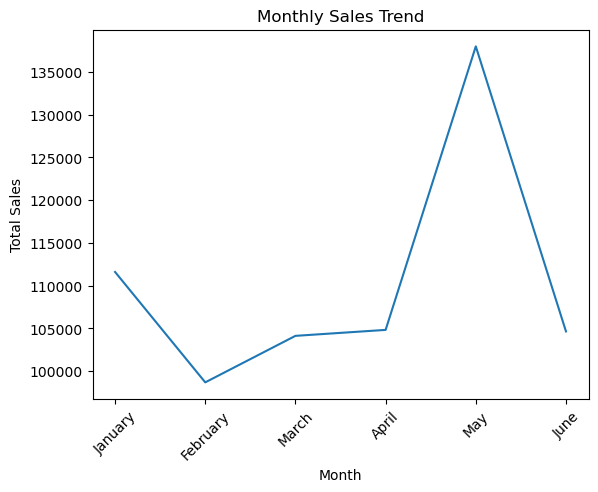

In [10]:
year_selected = 2025
df_year = df[df['PurchaseDate'].dt.year == year_selected]
# تجميع شهري
monthly_sales = df_year.groupby(
    df_year['PurchaseDate'].dt.month
)['TotalPrice'].sum().sort_index()

# أسماء الشهور
month_names = [calendar.month_name[i] for i in monthly_sales.index]

# الرسم
plt.figure()
plt.plot(month_names, monthly_sales.values)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)
plt.show()

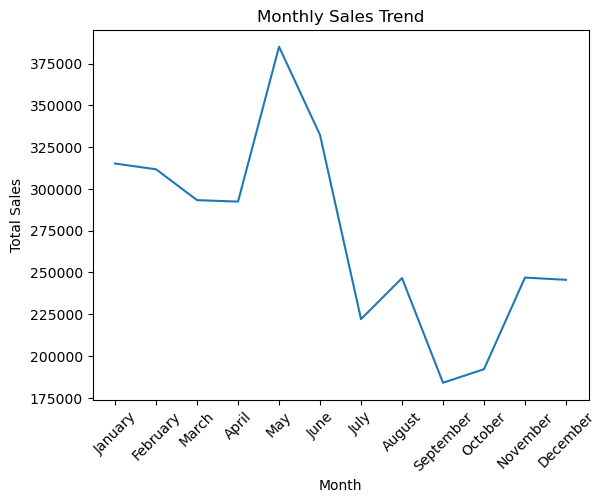

In [8]:

df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])
df['Month'] = df['PurchaseDate'].dt.month_name()
monthly_sales = df.groupby('Month')['TotalPrice'].sum()

# ترتيب الشهور
months_order = ['January','February','March','April','May','June',
                'July','August','September','October','November','December']

monthly_sales = monthly_sales.reindex(months_order)
plt.figure()
plt.plot(monthly_sales.index, monthly_sales.values)
plt.xticks(rotation=45)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [21]:
print("عدد السنوات:", df['PurchaseDate'].dt.year.unique())
print("إجمالي المبيعات:", df['TotalPrice'].sum())
print("أول 10 شهور مجمعة:")
print(df.groupby(df['PurchaseDate'].dt.to_period('M'))['TotalPrice'].sum().head(20))

عدد السنوات: [2024 2025 2023]
إجمالي المبيعات: 3266656.8
أول 10 شهور مجمعة:
PurchaseDate
2023-01     98390.67
2023-02    109746.60
2023-03     91665.47
2023-04     85517.05
2023-05    117663.53
2023-06    119837.23
2023-07    119476.63
2023-08    116736.14
2023-09     85040.67
2023-10     87857.58
2023-11    136455.33
2023-12    112883.28
2024-01    105158.94
2024-02    103280.28
2024-03     97450.02
2024-04    102020.38
2024-05    129387.77
2024-06    107748.12
2024-07    102536.36
2024-08    129835.63
Freq: M, Name: TotalPrice, dtype: float64
